In [2]:
import os

from getdist import plots, loadMCSamples
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use(
    "/home/guerrini/matplotlib_config/paper.mplstyle"
)

sns.set_palette("husl")

g = plots.get_subplot_plotter(width_inch=30)
g.settings.axes_fontsize=60
g.settings.axes_labelsize=60
g.settings.alpha_filled_add = 0.7
g.settings.legend_fontsize = 50

%matplotlib inline

#SPECIFY DATA DIRECTORY AND DESIRED CHAINS TO ANALYSE
root_dir = "/n09data/guerrini/output_chains/"
root_external = "/n09data/guerrini/output_chains/ext_data/"

roots = [
    "SP_v1.4.6_leak_corr_A_fid_cell",
    "SP_v1.4.6_leak_corr_A_10_80",
    "Planck18"
]

categories = [
    "harmonic",
    "configuration",
    "external"
]

print(roots)

os.makedirs("plots", exist_ok=True)
os.makedirs("plots/cosmological_constraints_cl_vs_xi", exist_ok=True)

['SP_v1.4.6_leak_corr_A_fid_cell', 'SP_v1.4.6_leak_corr_A_10_80', 'Planck18']


In [3]:
# MAKE PARAMNAMES FILE

for i, root in enumerate(roots):
    if categories[i] != "external":
        with open(root_dir + '{}/samples_{}.txt'.format('/'+root ,root), "r") as file:
            params = file.readline()[1:].split('\t')[:-4]
            file.close()
    
        with open(root_dir + '{}/getdist_{}.paramnames'.format('/'+root, root), "w") as file:
            for i in range(len(params)):
                if len(params[i].split('--')) > 1:
                    file.write(params[i].split('--')[1] + '\n')
                else:
                    file.write(params[i].split('--')[0] + '\n')
            file.close()

In [4]:
#READ CHAIN

chains=[]

for i, root in enumerate(roots):

    if categories[i] != "external":
        samples = np.loadtxt(root_dir + '{}/samples_{}.txt'.format(root,root))
        print(len(samples))
        if 'nautilus' in root:
            samples = np.column_stack((np.exp(samples[:,-3]),samples[:,-1]-samples[:,-2],samples[:,0:-3]))
        else:
            samples = np.column_stack((samples[:,-1],samples[:,-3],samples[:,0:-4]))
        np.savetxt(root_dir + '{}/getdist_{}.txt'.format(root,root), samples)

    root_dir_ = root_external if categories[i]=="external" else root_dir
    
    chain = g.samples_for_root(root_dir_ + '{}/getdist_{}'.format(root,root),
                               cache=False,
                               settings={'ignore_rows':0,
                                         'smooth_scale_2D':0.5,
                                         'smooth_scale_1D':0.5})

    chains.append(chain)

1728
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_fid_cell/getdist_SP_v1.4.6_leak_corr_A_fid_cell.txt
Removed no burn in
1618
/n09data/guerrini/output_chains/SP_v1.4.6_leak_corr_A_10_80/getdist_SP_v1.4.6_leak_corr_A_10_80.txt
Removed no burn in
/n09data/guerrini/output_chains/ext_data/Planck18/getdist_Planck18_1.txt
/n09data/guerrini/output_chains/ext_data/Planck18/getdist_Planck18_2.txt
/n09data/guerrini/output_chains/ext_data/Planck18/getdist_Planck18_3.txt
/n09data/guerrini/output_chains/ext_data/Planck18/getdist_Planck18_4.txt
Removed no burn in


In [26]:
name_list = ['OMEGA_M','ombh2','h0','n_s','SIGMA_8','s_8_input', 'logt_agn','a','m1','bias_1']
label_list = ['\Omega_m', '\omega_b h^2', 'h_0', 'n_s', '\sigma_8', 'S_8', 'log T_{AGN}', 'A_{IA}', 'm_1', '\Delta z_1']

for chain in chains:
    param_names = chain.getParamNames()
    for name, label in zip(name_list, label_list):
        try:
            param_names.parWithName(name).label = label
        except:
            pass

#Adjust Planck Omega_m name
planck_chain = chains[-1]
param_names = planck_chain.getParamNames()
planck_chain.index.update({'OMEGA_M': planck_chain.index['omega_m']})
param_names.parWithName('omega_m').label = r'\Omega_m'
param_names.parWithName('omega_m').name = 'OMEGA_M'

AttributeError: 'NoneType' object has no attribute 'label'

/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/getdist/plots.py:3347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.savefig(fname, bbox_extra_artists=self.extra_artists, bbox_inches='tight', **kwargs)
/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


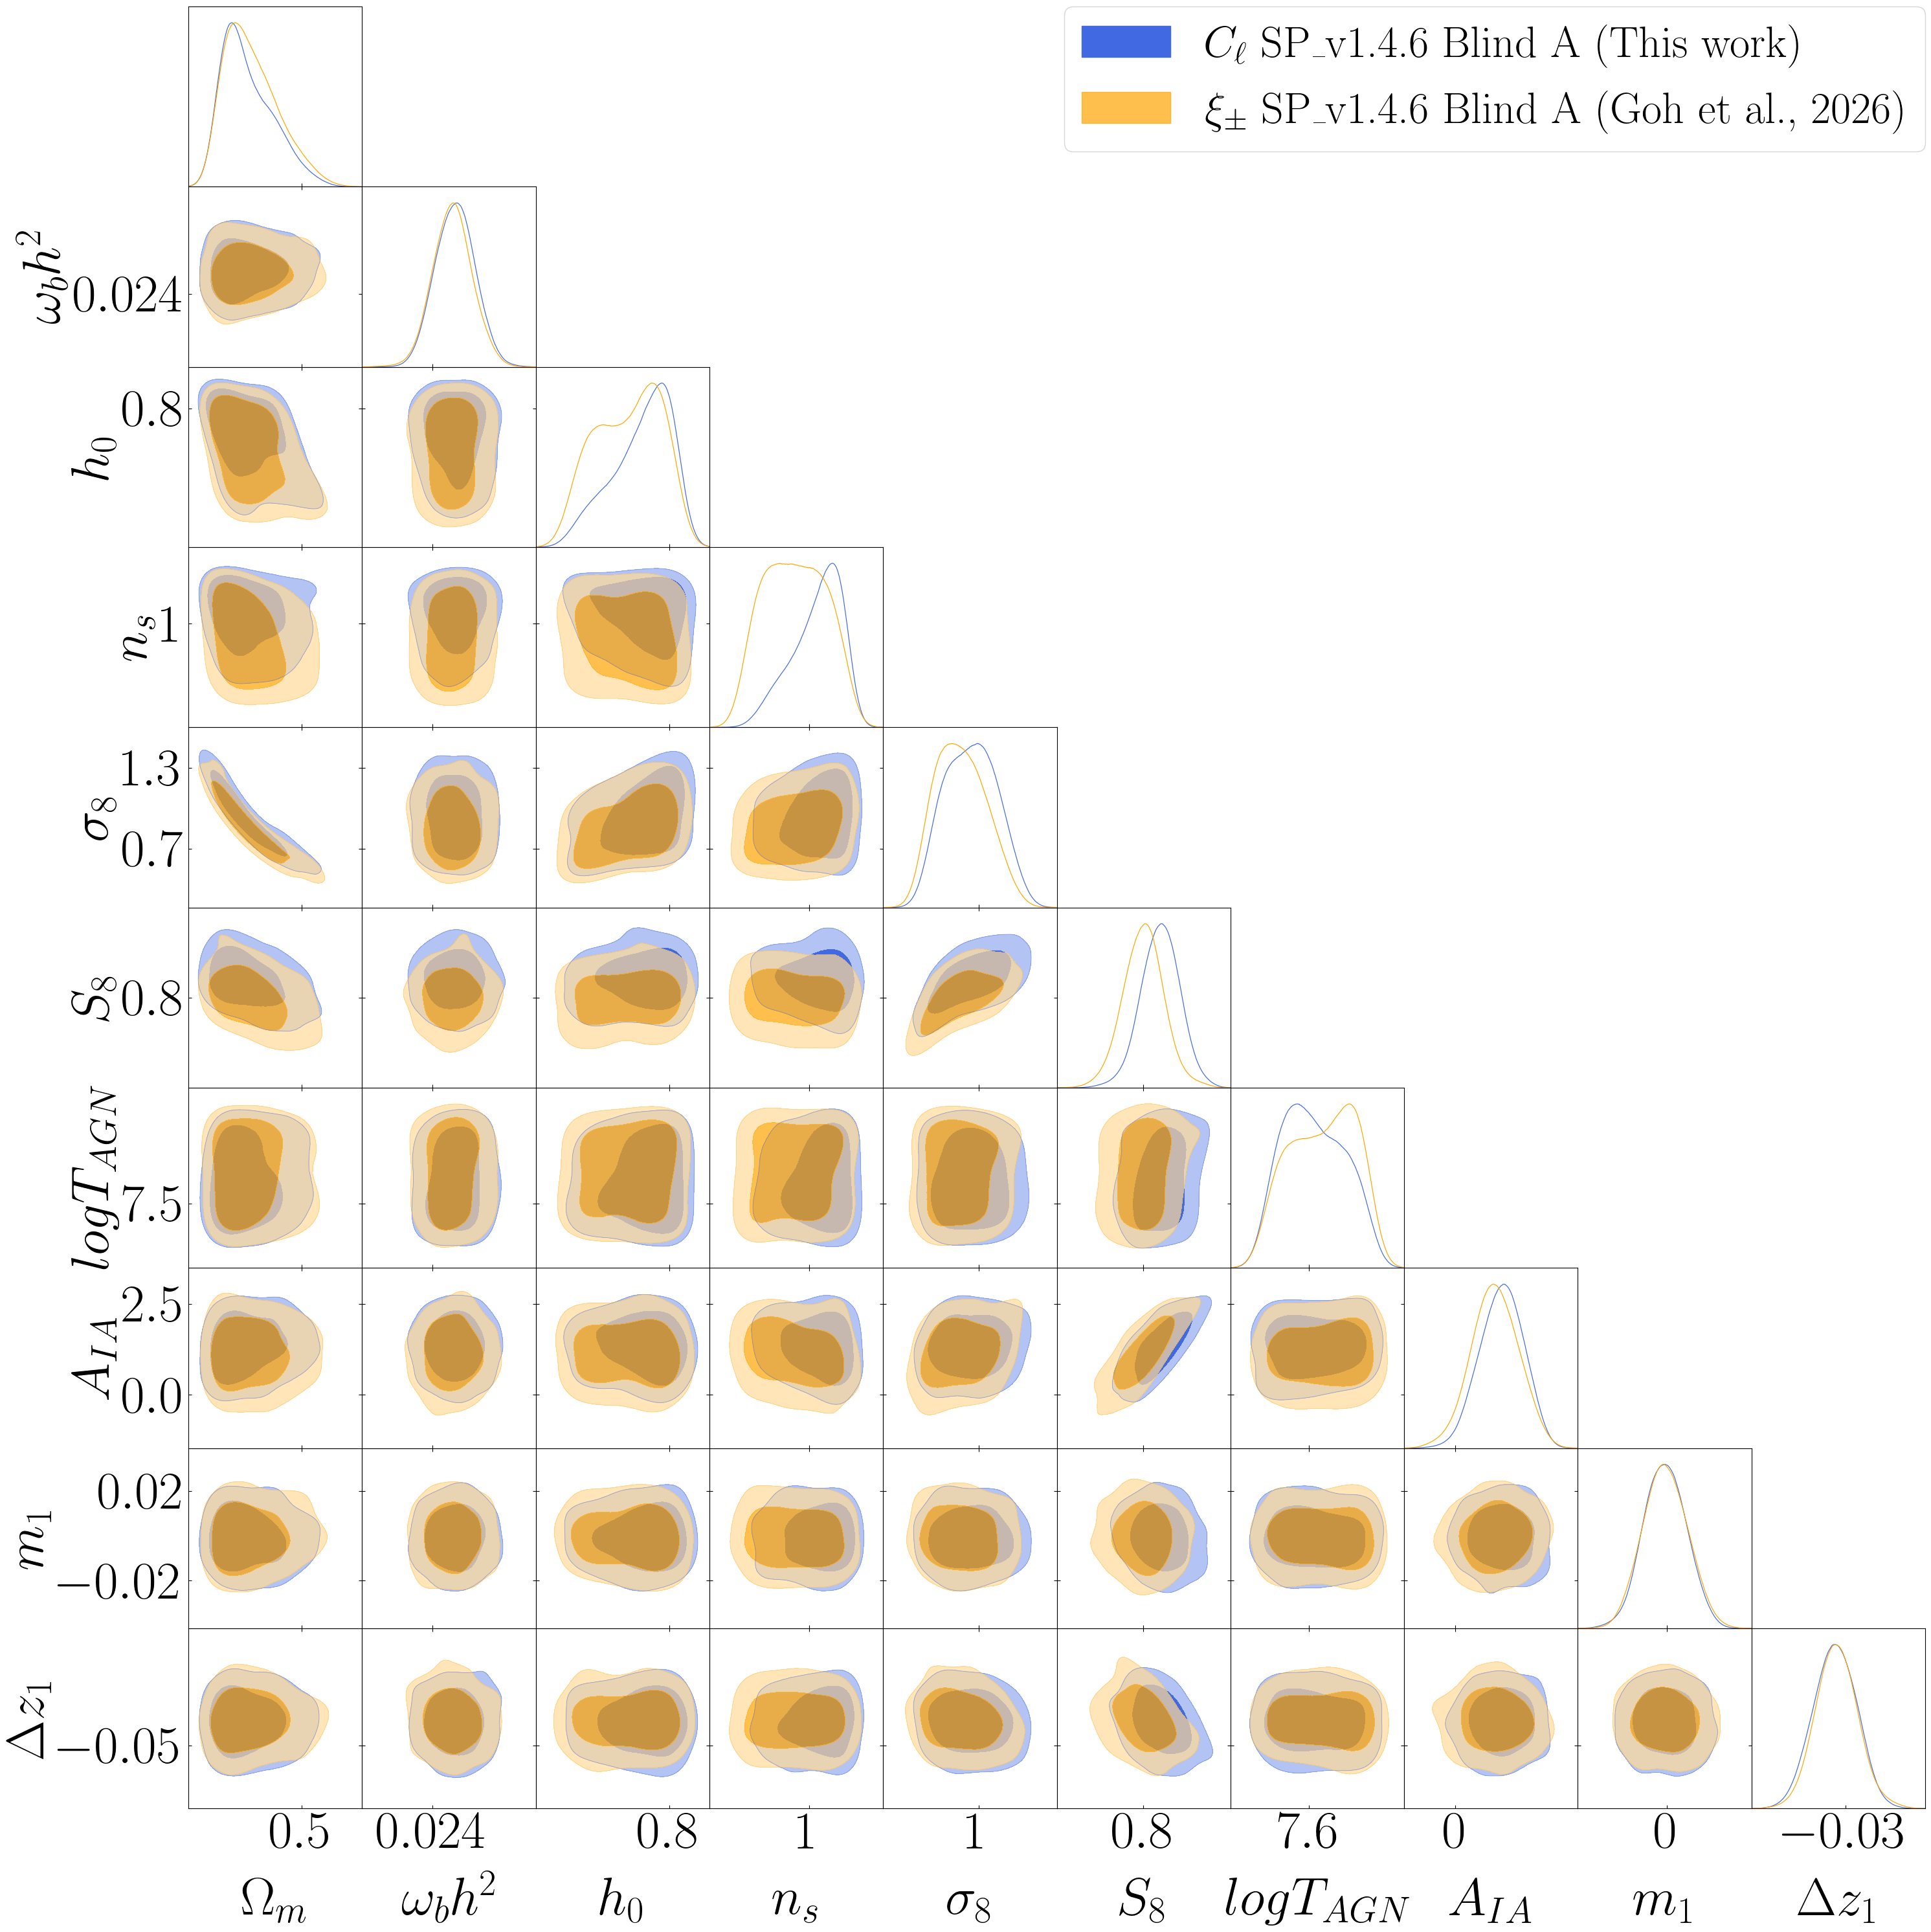

In [ ]:
legend_labels = [
    r"$C_\ell$ SP_v1.4.6 Blind A (This work)",
    r"$\xi_\pm$ SP_v1.4.6 Blind A (Goh et al., 2026)",
    r"Planck 2018"
]

colours = [
    "royalblue",
    "orange",
    "violet"
]

linestyle = [
    'solid',
    'solid',
    'solid'
]

line_args = [dict(color=col, ls=ls) for col, ls in zip(colours, linestyle)]

#Plot all parameters
g.triangle_plot(
    chains[:-1], # Plot everything but Planck
    ['OMEGA_M','ombh2', 'h0','n_s','SIGMA_8','s_8_input', 'logt_agn','a','m1','bias_1'],
    legend_labels=legend_labels,
    line_args=line_args,
    contour_colors=colours,
    legend_loc='upper right',

    filled=True
)

g.export('plots/cosmological_constraints_cl_vs_xi/contours_all_cell.png')
plt.show()

/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/getdist/plots.py:3347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.savefig(fname, bbox_extra_artists=self.extra_artists, bbox_inches='tight', **kwargs)
/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


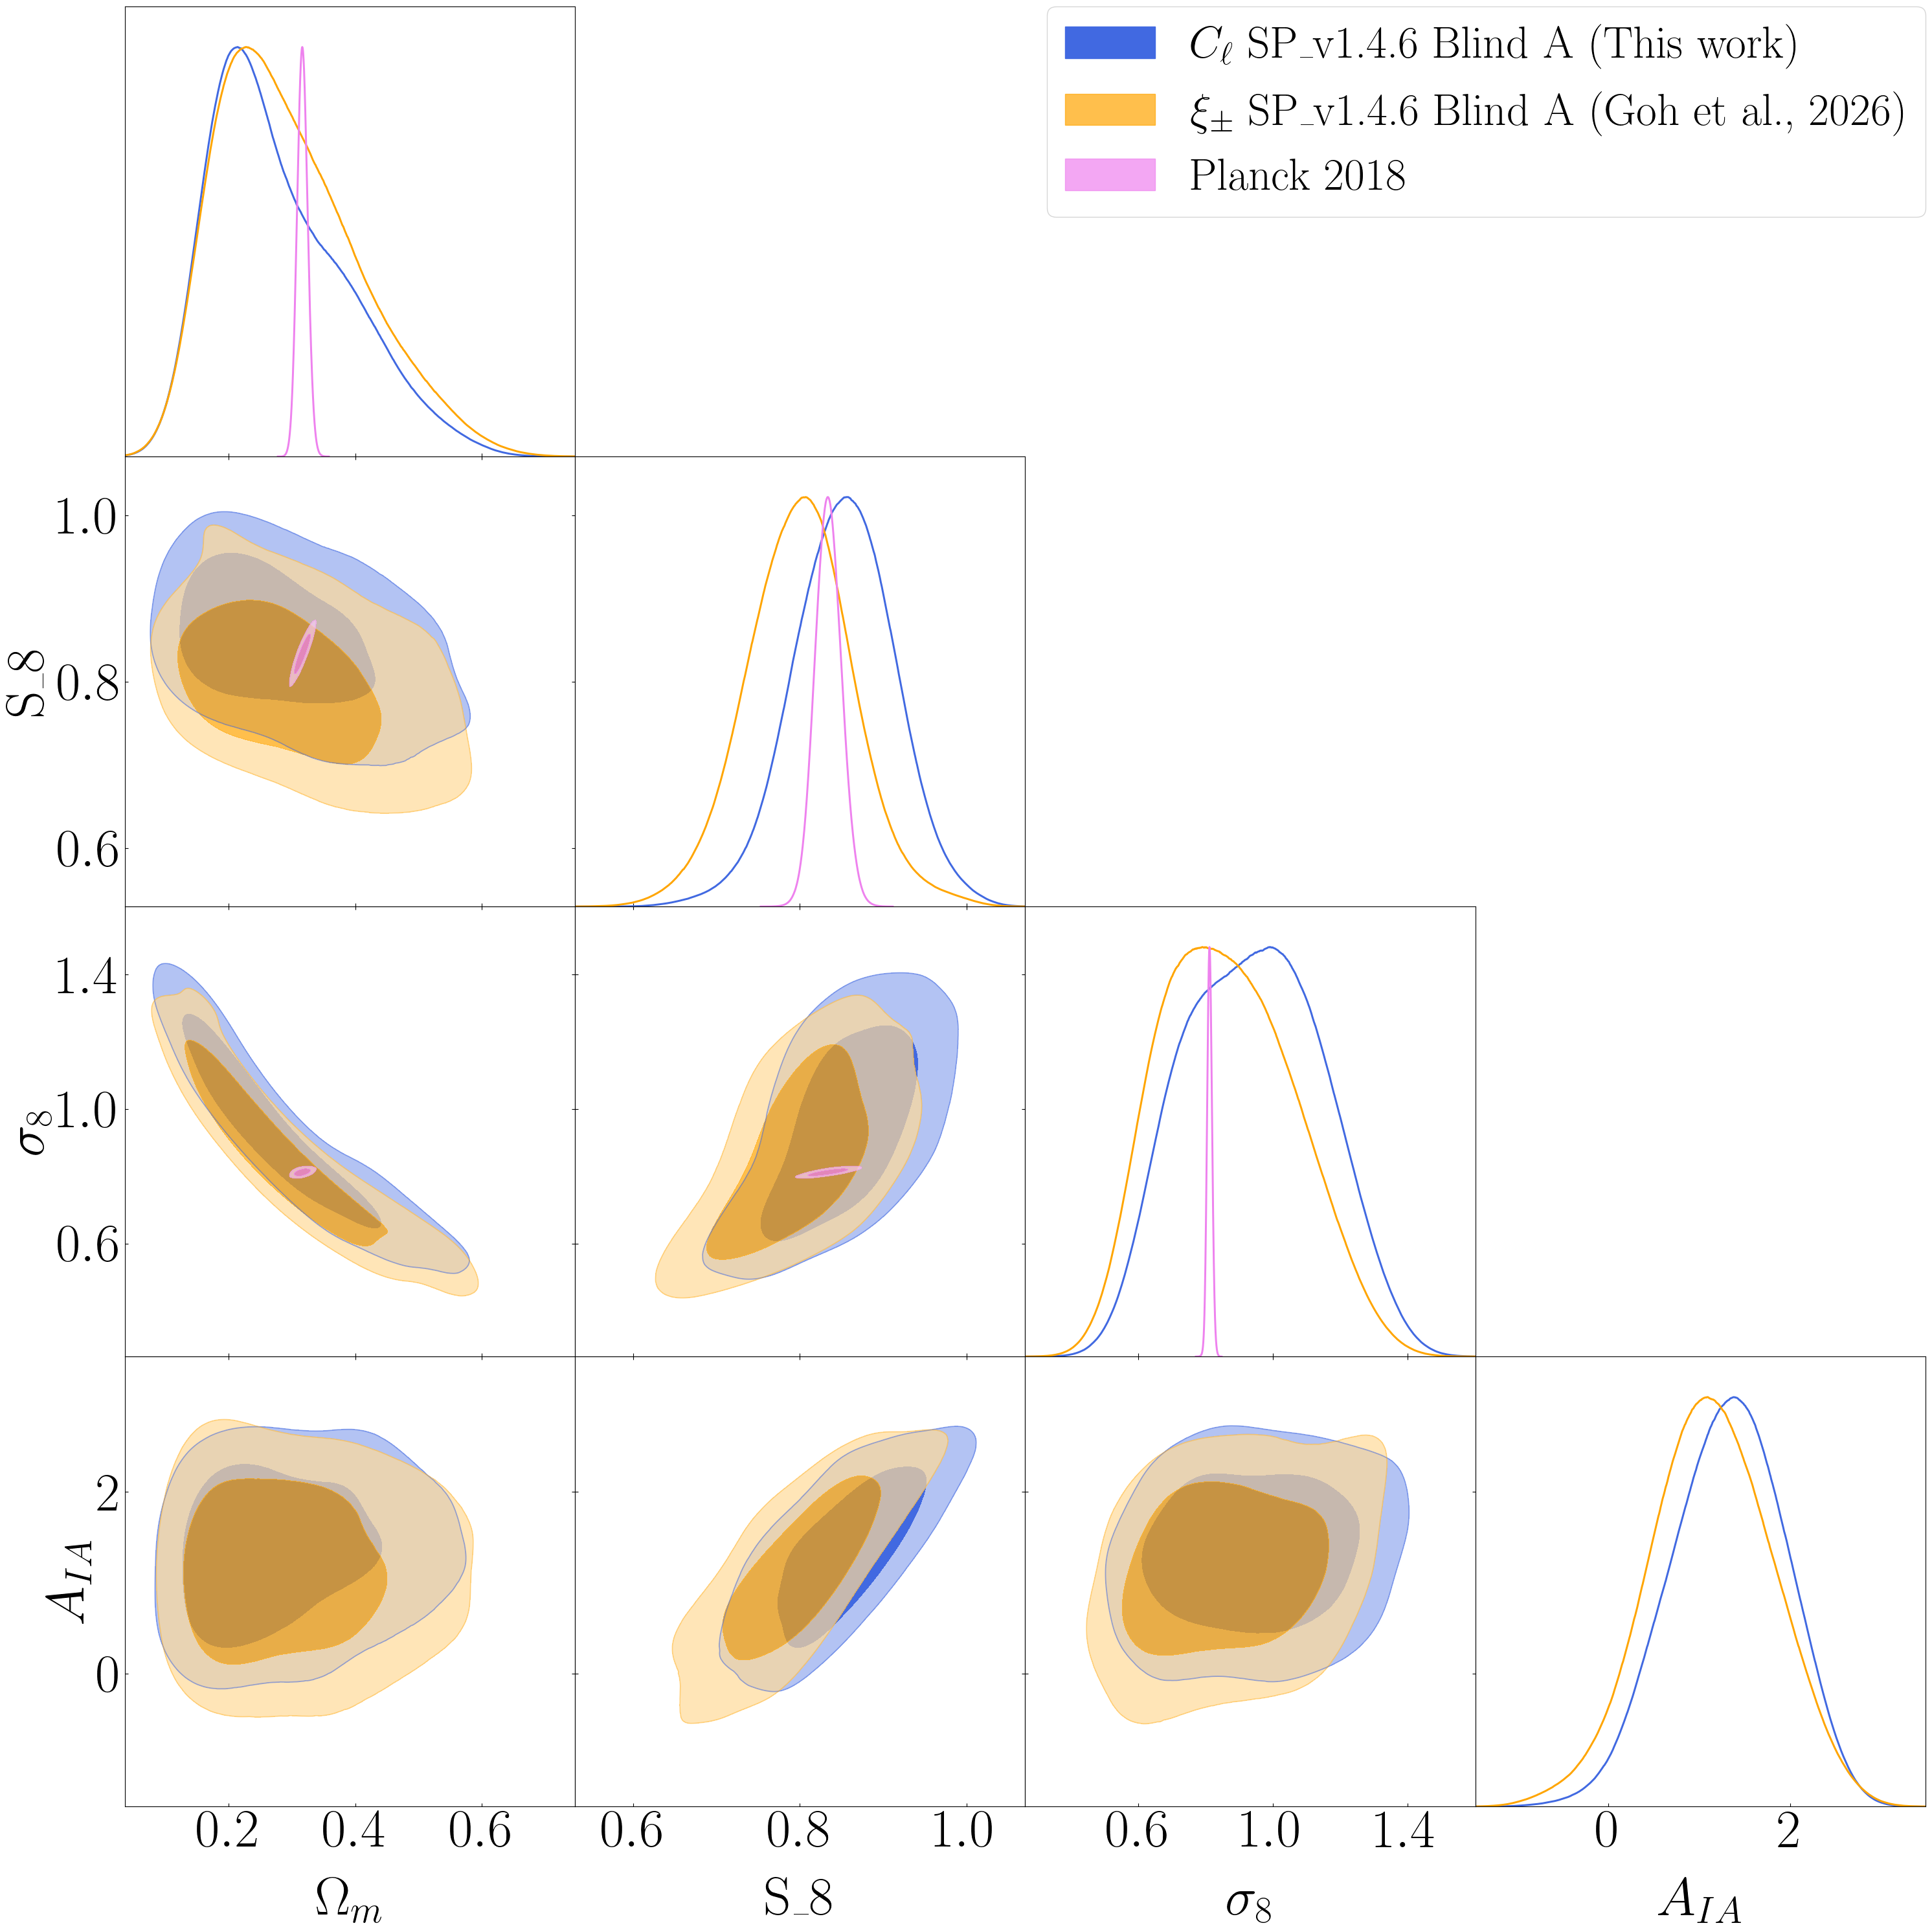

In [31]:
#Plot only cosmological parameters

g.triangle_plot(
    chains,
    ['OMEGA_M','S_8', 'SIGMA_8', 'a'],
    legend_labels=legend_labels,
    line_args=line_args,
    contour_colors=colours,
    legend_loc='upper right',
    filled=True
)

g.export('plots/cosmological_constraints_cl_vs_xi/contours_cosmo_cell.png')
plt.show()

/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/getdist/plots.py:3347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.savefig(fname, bbox_extra_artists=self.extra_artists, bbox_inches='tight', **kwargs)
/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


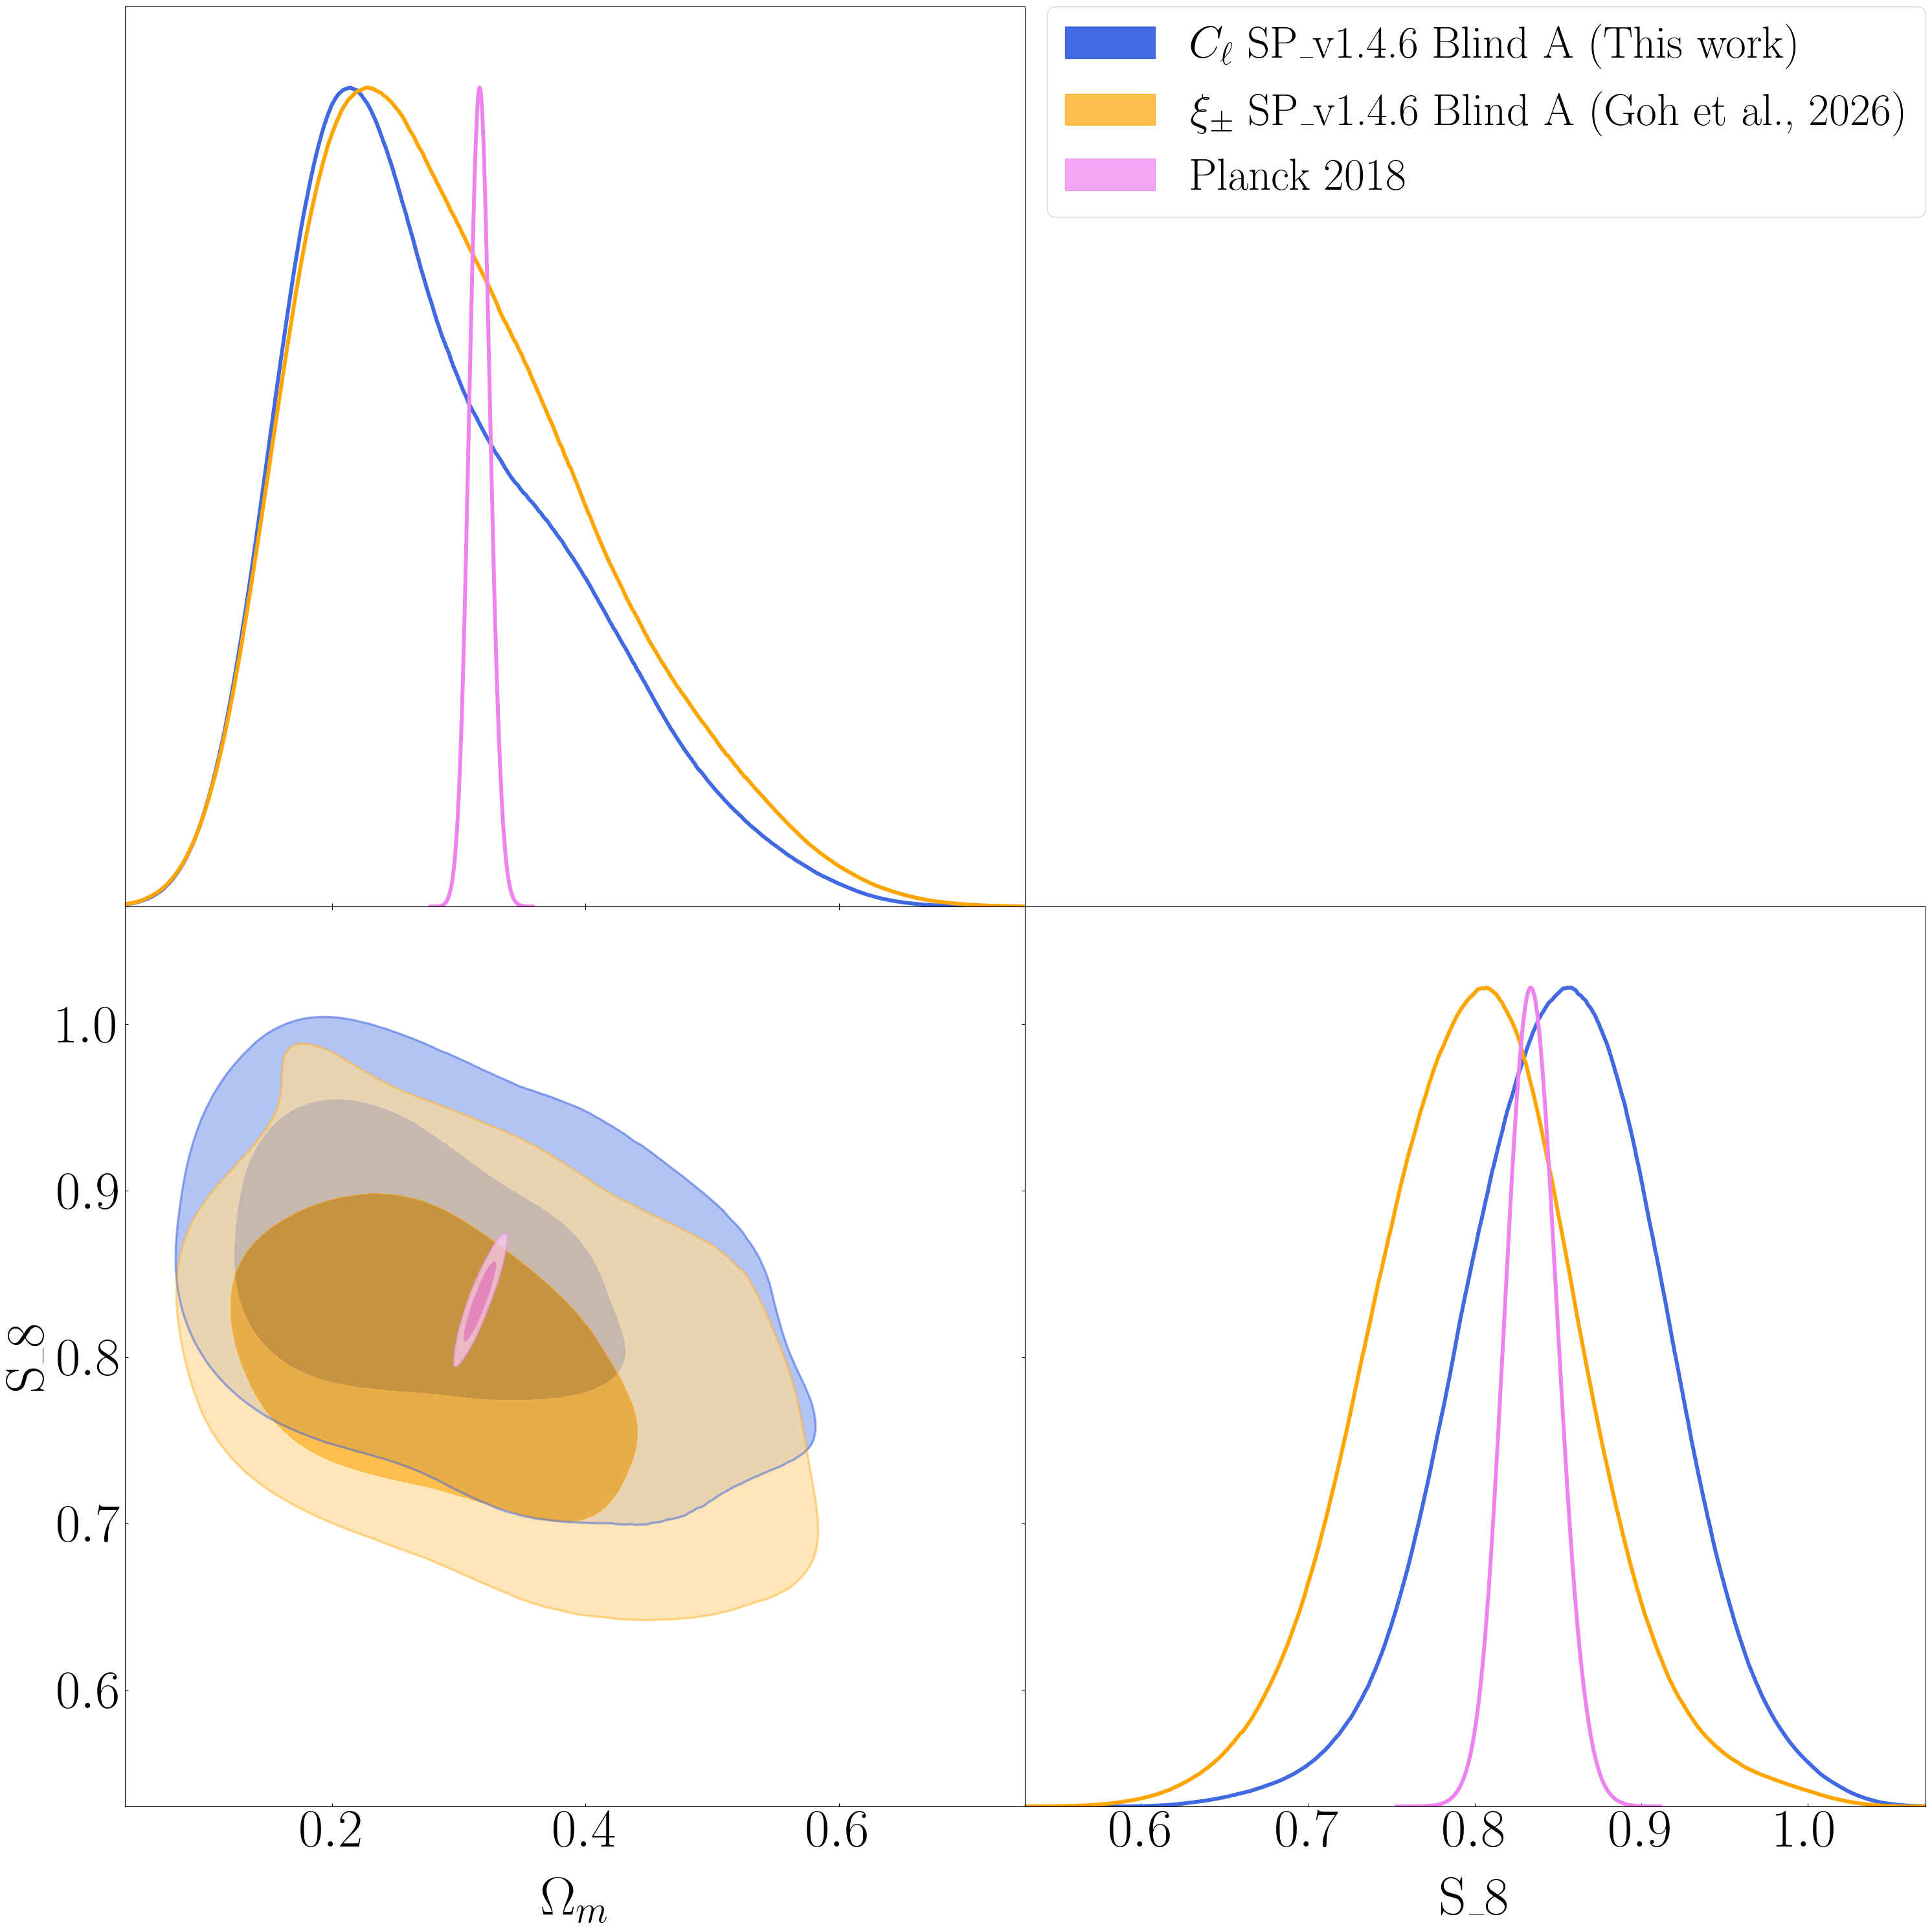

In [32]:
#Plot S8 Omega_m only
g.triangle_plot(
    chains,
    ['OMEGA_M','S_8'],
    legend_labels=legend_labels,
    legend_loc='upper right',
    line_args=line_args,
    contour_colors=colours,
    filled=True,
)

""" plt.figtext(0.5, 0.5, 'PRELIMINARY',
            fontsize=150, color='gray',
            ha='center', va='center',
            alpha=0.3, rotation=330) """

g.export('plots/cosmological_constraints_cl_vs_xi/contours_s8_omegam_cell.png')
plt.show()